In [4]:
import numpy as np
import matplotlib.pyplot as plt
from heston.closed import heston_call_price
from black_scholes.bs import black_scholes

In [26]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

In [31]:
print(black_scholes(S0, K, r, np.sqrt(v0), T, 'call'))

10.450583572185565


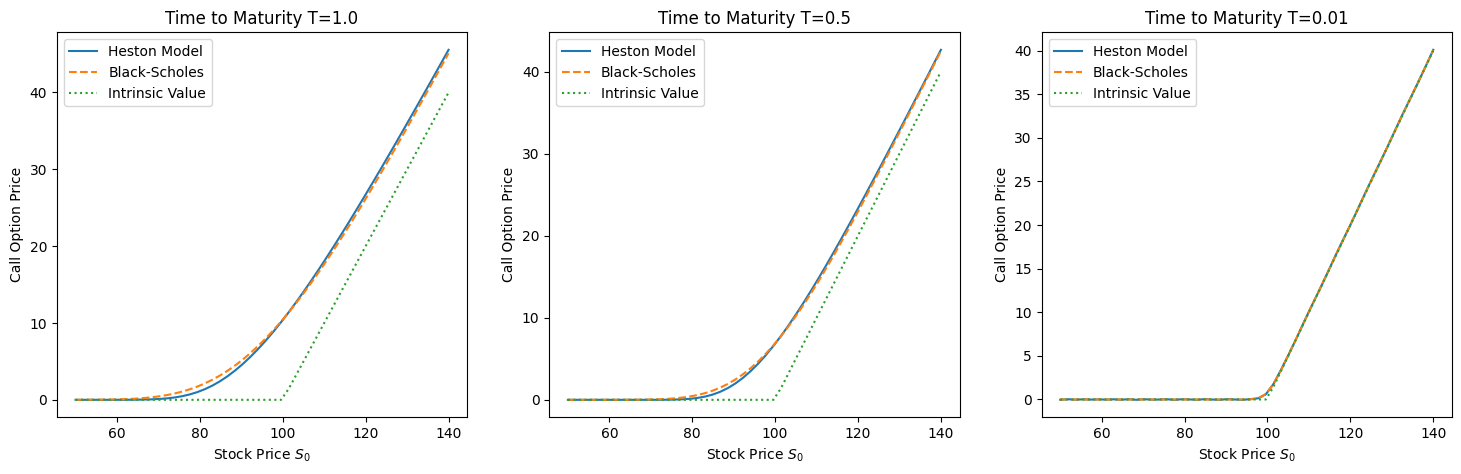

In [39]:
S = np.linspace(50, 140, 50)
intrinsic_values = np.maximum(S - K, 0)

Ts = [1.0, 0.5, 0.01]

plt.figure(figsize=(18, 5))
for i, T in enumerate(Ts):
    prices = [heston_call_price(S0, K, T, r, kappa, theta, sigma, rho, v0) for S0 in S]
    bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T, 'call') for S0 in S]
    plt.subplot(1, 3, i+1)
    plt.plot(S, prices, label='Heston Model')
    plt.plot(S, bs_prices, label='Black-Scholes', linestyle='--')
    plt.plot(S, intrinsic_values, label='Intrinsic Value', linestyle=':')
    plt.title(f'Time to Maturity T={T}')
    plt.xlabel('Stock Price $S_0$')
    plt.ylabel('Call Option Price')
    plt.legend()
plt.show()